In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.special import gamma
from scipy.integrate import quad


# Acquisition et Visualisation des Données

## 1. Echantillon de loi de Weibull

In [3]:
# Paramètres choisis
beta = 2      # paramètre de forme
eta  = 3      # paramètre d'échelle (en milliers d'heures)
n    = 1000   # taille de l'échantillon

# Génération de l'échantillon
np.random.seed(42)
T = eta * np.random.weibull(beta, n)

E_theo = eta * gamma(1 + 1/beta)
V_theo = eta**2 * (gamma(1 + 2/beta) - gamma(1 + 1/beta)**2)

print(f"=== Vérification ===")
print(f"Moyenne empirique  : {T.mean():.4f}  |  Théorique : {E_theo:.4f}")
print(f"Écart-type empirique: {T.std():.4f}  |  Théorique : {V_theo**0.5:.4f}")

=== Vérification ===
Moyenne empirique  : 2.6141  |  Théorique : 2.6587
Écart-type empirique: 1.3853  |  Théorique : 1.3898


## 2. Histogramme des durées de vie

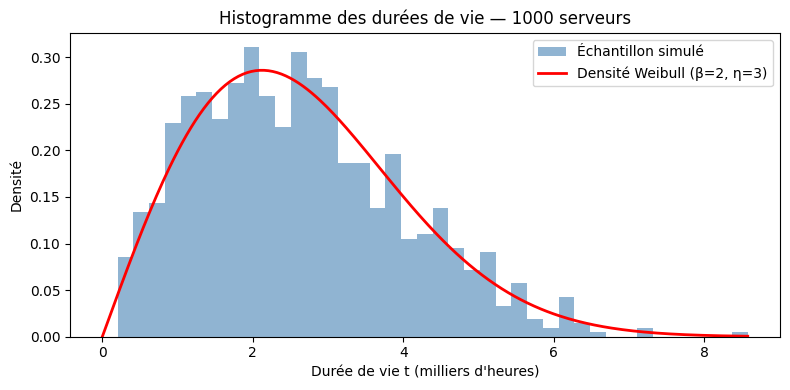

In [21]:
t_range = np.linspace(0, T.max(), 300)
f_theo  = (beta/eta) * (t_range/eta)**(beta-1) * np.exp(-(t_range/eta)**beta)

plt.figure(figsize=(8,4))
plt.hist(T, bins=40, density=True, alpha=0.6, color='steelblue', label='Échantillon simulé')
plt.plot(t_range, f_theo, 'r-', lw=2, label=f'Densité Weibull (β={beta}, η={eta})')
plt.xlabel('Durée de vie t (milliers d\'heures)')
plt.ylabel('Densité')
plt.title('Histogramme des durées de vie — 1000 serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('histogramme.png', dpi=150)
plt.show()

## 3. Fiabilité empirique R(t)


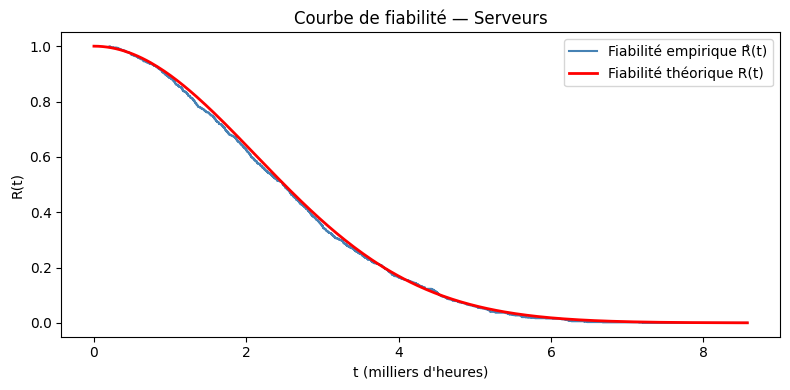

In [22]:
# ── Fiabilité empirique ──────────────────────────────────
T_sorted = np.sort(T)
R_emp    = 1 - np.arange(1, n+1) / n          # R̂(t) = nb vivants / nb total
R_theo   = np.exp(-(t_range/eta)**beta)        # R(t) théorique

plt.figure(figsize=(8,4))
plt.step(T_sorted, R_emp, color='steelblue', lw=1.5, label='Fiabilité empirique R̂(t)')
plt.plot(t_range, R_theo, 'r-', lw=2, label='Fiabilité théorique R(t)')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('R(t)')
plt.title('Courbe de fiabilité — Serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('fiabilite.png', dpi=150)
plt.show()

## 4. Taux de défaillance empirique λ(t)

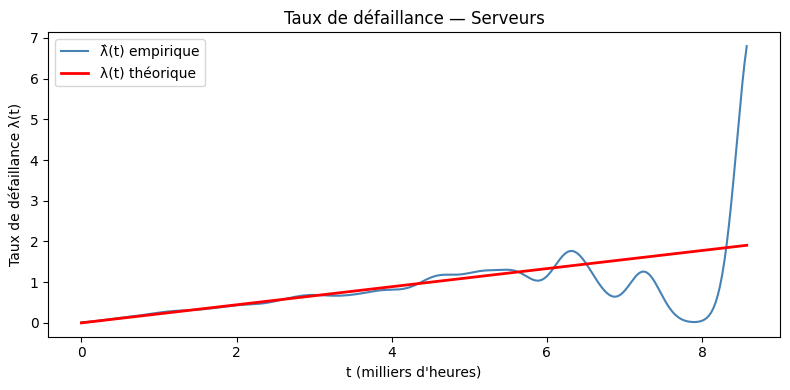

In [23]:
# ── Taux de défaillance empirique ────────────────────────
# f̂(t) via KDE, λ̂(t) = f̂(t) / R̂(t)

kde      = gaussian_kde(T, bw_method=0.15)
f_emp    = kde(t_range)
R_emp_c  = np.exp(-(t_range/eta)**beta)        # on utilise R théorique pour lisser
lambda_emp  = f_emp / R_emp_c
lambda_theo = (beta/eta) * (t_range/eta)**(beta-1)

plt.figure(figsize=(8,4))
plt.plot(t_range, lambda_emp,  color='steelblue', lw=1.5, label='λ̂(t) empirique')
plt.plot(t_range, lambda_theo, 'r-', lw=2,        label='λ(t) théorique')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('Taux de défaillance λ(t)')
plt.title('Taux de défaillance — Serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('taux_defaillance.png', dpi=150)
plt.show()

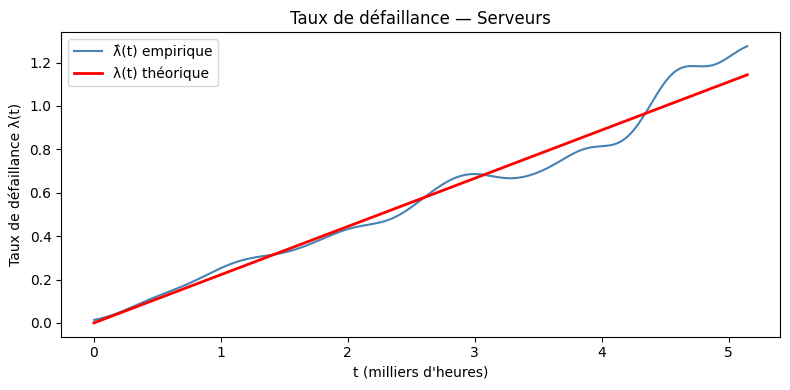

In [24]:
# ── Taux de défaillance empirique ────────────────────────
# f̂(t) via KDE, λ̂(t) = f̂(t) / R̂(t)

t_max_95 = np.percentile(T, 95)
t_range_95 = np.linspace(0, t_max_95, 300)

kde      = gaussian_kde(T, bw_method=0.15)
f_emp    = kde(t_range_95)
R_emp_c  = np.exp(-(t_range_95/eta)**beta)        # on utilise R théorique pour lisser
lambda_emp  = f_emp / R_emp_c
lambda_theo = (beta/eta) * (t_range_95/eta)**(beta-1)

plt.figure(figsize=(8,4))
plt.plot(t_range_95, lambda_emp,  color='steelblue', lw=1.5, label='λ̂(t) empirique')
plt.plot(t_range_95, lambda_theo, 'r-', lw=2,        label='λ(t) théorique')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('Taux de défaillance λ(t)')
plt.title('Taux de défaillance — Serveurs')
plt.legend()
plt.tight_layout()
plt.savefig('taux_defaillance_corrigé.png', dpi=150)
plt.show()

# Estimation des Paramètres ("Papier de Weibull")

## 2. Estimation de β et η par régression linéaire

=== Estimation des paramètres ===
β réel : 2.000  |  β estimé : 2.008
η réel : 3.000  |  η estimé : 2.936


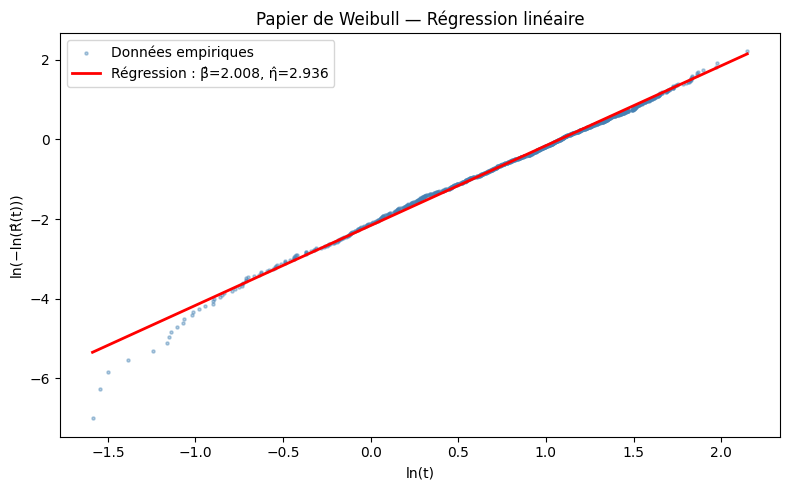

In [35]:
# ── Papier de Weibull ────────────────────────────────────
# On utilise la formule de Hazen pour éviter ln(0)
R_hazen = 1 - (np.arange(1, n+1) - 0.1) / n

# Transformation linéarisante
X = np.log(T_sorted)               # ln(t)
Y = np.log(-np.log(R_hazen))       # ln(-ln(R̂(t)))

# Régression linéaire
coeffs   = np.polyfit(X, Y, 1)
beta_est = coeffs[0]               # pente = β̂
eta_est  = np.exp(-coeffs[1] / beta_est)  # ordonnée → η̂

print(f"=== Estimation des paramètres ===")
print(f"β réel : {beta:.3f}  |  β estimé : {beta_est:.3f}")
print(f"η réel : {eta:.3f}  |  η estimé : {eta_est:.3f}")

# ── Tracé du Papier de Weibull ───────────────────────────
X_line = np.linspace(X.min(), X.max(), 200)
Y_line = beta_est * X_line - beta_est * np.log(eta_est)

plt.figure(figsize=(8,5))
plt.scatter(X, Y, s=5, alpha=0.4, color='steelblue', label='Données empiriques')
plt.plot(X_line, Y_line, 'r-', lw=2,
         label=f'Régression : β̂={beta_est:.3f}, η̂={eta_est:.3f}')
plt.xlabel('ln(t)')
plt.ylabel('ln(−ln(R̂(t)))')
plt.title('Papier de Weibull — Régression linéaire')
plt.legend()
plt.tight_layout()
plt.savefig('papier_weibull.png', dpi=150)
plt.show()

# Optimisation de l'architecture

## 1. Echantillons de loi exponentielle

In [26]:
# ── Paramètres des composants ────────────────────────────
mu1 = 1/2.0   # composant 1 : durée moyenne = 2000h
mu2 = 1/3.0   # composant 2 : durée moyenne = 3000h
N   = 10000
np.random.seed(42)

# Simulation lois exponentielles
T1 = np.random.exponential(scale=1/mu1, size=N)
T2 = np.random.exponential(scale=1/mu2, size=N)

print(f"Moyenne T1 : {T1.mean():.4f}  |  Théorique : {1/mu1:.4f}")
print(f"Moyenne T2 : {T2.mean():.4f}  |  Théorique : {1/mu2:.4f}")

Moyenne T1 : 1.9550  |  Théorique : 2.0000
Moyenne T2 : 3.0556  |  Théorique : 3.0000


## 2. Durée de vie de système en série

In [27]:
# ── Série : le système meurt si L'UN tombe ───────────────
T_serie = np.minimum(T1, T2)

E_serie_emp  = T_serie.mean()
E_serie_theo = 1 / (mu1 + mu2)

print(f"\n=== Série ===")
print(f"Moyenne empirique  : {E_serie_emp:.4f}")
print(f"Moyenne théorique  : {E_serie_theo:.4f}")


=== Série ===
Moyenne empirique  : 1.1919
Moyenne théorique  : 1.2000


## 3. Durée de vie de système en parallèle

In [28]:
# ── Parallèle : le système meurt si LES DEUX tombent ─────
T_para = np.maximum(T1, T2)

E_para_emp  = T_para.mean()
E_para_theo = 1/mu1 + 1/mu2 - 1/(mu1+mu2)

print(f"\n=== Parallèle ===")
print(f"Moyenne empirique  : {E_para_emp:.4f}")
print(f"Moyenne théorique  : {E_para_theo:.4f}")


=== Parallèle ===
Moyenne empirique  : 3.8187
Moyenne théorique  : 3.8000


## 4. Comparaison


Montage         Empirique    Théorique
---------------------------------------------
Série              1.1919       1.2000
Parallèle          3.8187       3.8000
Gain x               3.20         3.17


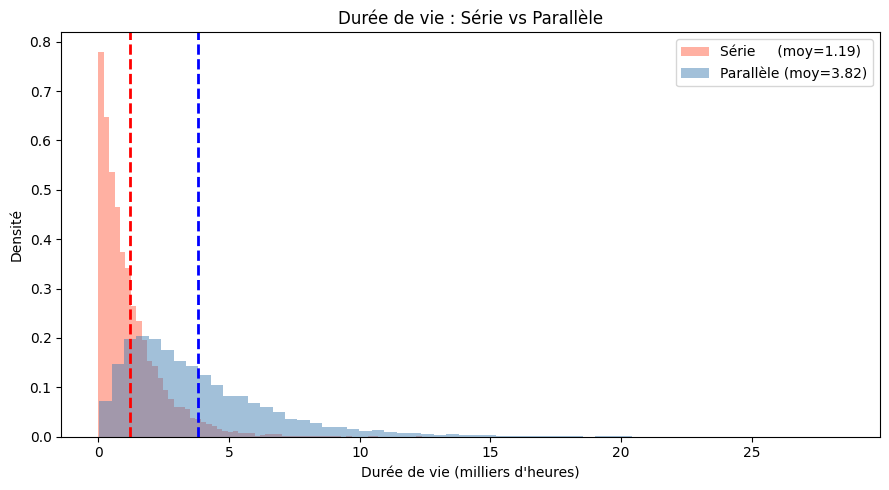

In [29]:
# ── Tableau comparatif ───────────────────────────────────
print(f"\n{'='*45}")
print(f"{'Montage':<12} {'Empirique':>12} {'Théorique':>12}")
print(f"{'-'*45}")
print(f"{'Série':<12} {E_serie_emp:>12.4f} {E_serie_theo:>12.4f}")
print(f"{'Parallèle':<12} {E_para_emp:>12.4f} {E_para_theo:>12.4f}")
print(f"{'Gain x':<12} {E_para_emp/E_serie_emp:>12.2f} {E_para_theo/E_serie_theo:>12.2f}")
print(f"{'='*45}")

# ── Histogramme comparatif ───────────────────────────────
plt.figure(figsize=(9,5))
plt.hist(T_serie, bins=60, density=True, alpha=0.5,
         color='tomato',     label=f'Série     (moy={E_serie_emp:.2f})')
plt.hist(T_para,  bins=60, density=True, alpha=0.5,
         color='steelblue',  label=f'Parallèle (moy={E_para_emp:.2f})')
plt.axvline(E_serie_emp, color='red',      lw=2, linestyle='--')
plt.axvline(E_para_emp,  color='blue',     lw=2, linestyle='--')
plt.xlabel('Durée de vie (milliers d\'heures)')
plt.ylabel('Densité')
plt.title('Durée de vie : Série vs Parallèle')
plt.legend()
plt.tight_layout()
plt.savefig('serie_vs_parallele.png', dpi=150)
plt.show()

# Durée de Survie et Maintenance

## 1. Probabilité de survie

In [30]:
# ── Paramètres ───────────────────────────────────────────
t = 1.5    # déjà fonctionné 1500h
x = 0.5    # 500h supplémentaires

# Fiabilité de Weibull
def R(t):
    return np.exp(-(t/eta)**beta)

# Probabilité de survie conditionnelle
prob = R(t + x) / R(t)

print(f"=== Survie conditionnelle ===")
print(f"R(t)       = R({t})   = {R(t):.6f}")
print(f"R(t+x)     = R({t+x}) = {R(t+x):.6f}")
print(f"P(T > {t+x} | T > {t}) = {prob:.6f}")
print(f"Soit environ {prob*100:.2f}% de chance de survivre 500h de plus")

=== Survie conditionnelle ===
R(t)       = R(1.5)   = 0.778801
R(t+x)     = R(2.0) = 0.641180
P(T > 2.0 | T > 1.5) = 0.823292
Soit environ 82.33% de chance de survivre 500h de plus


## 2. Temps moyen

In [31]:

# ── Intégration numérique ────────────────────────────────
def integrand(u):
    return R(u)

integrale, erreur = quad(integrand, t, np.inf)
E_residuelle = integrale / R(t)

print(f"\n=== Espérance de vie résiduelle ===")
print(f"Intégrale de R(u) de {t} à +∞ : {integrale:.6f}")
print(f"R({t})                          : {R(t):.6f}")
print(f"E[T_t]                          : {E_residuelle:.4f} milliers d'heures")
print(f"Soit environ {E_residuelle*1000:.1f} heures restantes en moyenne")


=== Espérance de vie résiduelle ===
Intégrale de R(u) de 1.5 à +∞ : 1.274838
R(1.5)                          : 0.778801
E[T_t]                          : 1.6369 milliers d'heures
Soit environ 1636.9 heures restantes en moyenne


## 3. Moment de remplacement


=== Décision de maintenance ===
Seuil critique λ* = C_rem/C_panne = 0.100
t* (remplacement recommandé)       = 0.4641 milliers d'heures
Soit environ 464 heures de fonctionnement


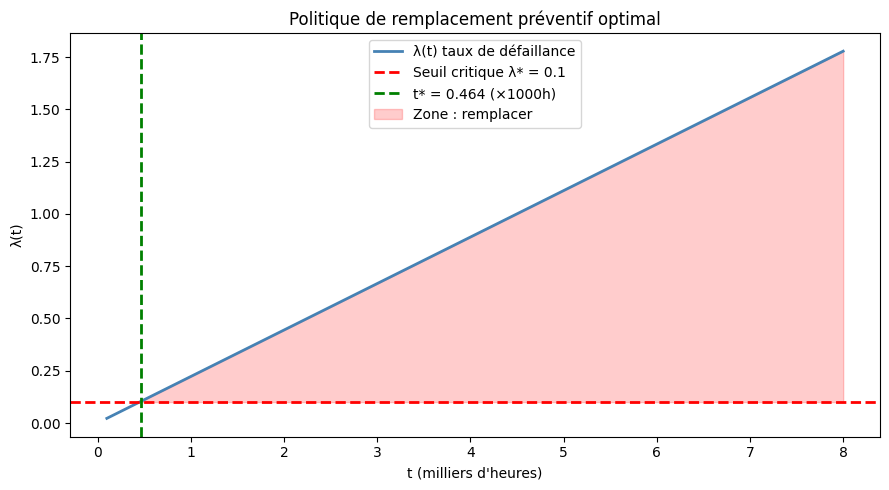

In [22]:
# ── Analyse coût-bénéfice ────────────────────────────────
cout_panne       = 10   # unités relatives
cout_remplacement = 1

# Pour chaque instant t, coût espéré si on attend vs si on remplace
t_vals = np.linspace(0.1, 8, 500)

# Taux de défaillance λ(t) = coût instantané du risque
lambda_vals = (beta/eta) * (t_vals/eta)**(beta-1)

# Seuil critique : λ(t*) = cout_remplacement / cout_panne
lambda_seuil = cout_remplacement / cout_panne  # = 0.1

# Trouver t* où λ(t) dépasse le seuil
idx_star = np.argmax(lambda_vals >= lambda_seuil)
t_star   = t_vals[idx_star]

print(f"\n=== Décision de maintenance ===")
print(f"Seuil critique λ* = C_rem/C_panne = {lambda_seuil:.3f}")
print(f"t* (remplacement recommandé)       = {t_star:.4f} milliers d'heures")
print(f"Soit environ {t_star*1000:.0f} heures de fonctionnement")

# ── Visualisation ────────────────────────────────────────
plt.figure(figsize=(9,5))
plt.plot(t_vals, lambda_vals, 'steelblue', lw=2, label='λ(t) taux de défaillance')
plt.axhline(lambda_seuil, color='red', lw=2, linestyle='--',
            label=f'Seuil critique λ* = {lambda_seuil}')
plt.axvline(t_star, color='green', lw=2, linestyle='--',
            label=f't* = {t_star:.3f} (×1000h)')
plt.fill_between(t_vals, lambda_vals, lambda_seuil,
                 where=(lambda_vals >= lambda_seuil),
                 alpha=0.2, color='red', label='Zone : remplacer')
plt.xlabel('t (milliers d\'heures)')
plt.ylabel('λ(t)')
plt.title('Politique de remplacement préventif optimal')
plt.legend()
plt.tight_layout()
plt.savefig('maintenance.png', dpi=150)
plt.show()